# NLP: классификация email на spam/ham

В этом журнале оставлены два способа получения эмбеддингов:

- BERT (`bert-base-uncased`);
- GPT-2 (`gpt2`).

In [1]:
!pip install -q transformers contractions nltk scikit-learn matplotlib seaborn

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress t

In [2]:
import random
import re

import contractions
import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
from transformers import AutoModel, AutoTokenizer, GPT2Model, GPT2Tokenizer

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

C:\Users\user\.cache\codex-runtimes\codex-primary-runtime\dependencies\python\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...


[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...


[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...


Device: cpu


## 1. Загрузка данных

In [3]:
df = pd.read_csv('email_text.csv')
df = df[['label', 'text']].head(1000).dropna().copy()

df['label'] = df['label'].astype(int)
df['text'] = df['text'].astype(str)

print(df.shape)
display(df.head())
print(df['label'].value_counts())
print(df['label'].value_counts(normalize=True))

(1000, 2)


,label,text
0,0,the mailing list i queried about a few weeks a...
1,1,luxury watches buy your own rolex for only esc...
2,1,academic qualifications available from prestig...
3,0,greetings all this is to verify your subscript...
4,1,try chauncey may conferred the luscious not co...


label
0    652
1    348
Name: count, dtype: int64
label
0    0.652
1    0.348
Name: proportion, dtype: float64


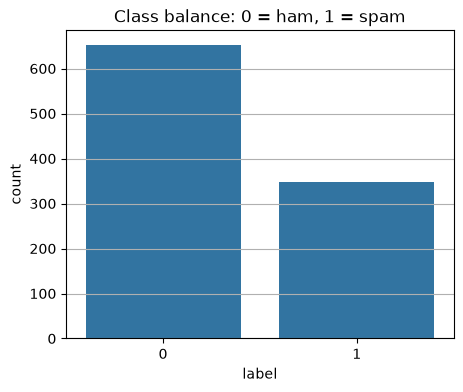

In [4]:
plt.figure(figsize=(5, 4))
sns.countplot(data=df, x='label')
plt.title('Class balance: 0 = ham, 1 = spam')
plt.grid(axis='y')
plt.show()

## 2. Предобработка текста

In [5]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()


def preprocess_text(text):
    text = contractions.fix(str(text))
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    tokens = []
    for token in text.split():
        if token not in stop_words and len(token) > 1:
            tokens.append(lemmatizer.lemmatize(token))

    return ' '.join(tokens)


df['clean_text'] = df['text'].apply(preprocess_text)
display(df[['label', 'clean_text']].head())

,label,clean_text
0,0,mailing list queried week ago running also set...
1,1,luxury watch buy rolex escapenumber rolex cart...
2,1,academic qualification available prestigious n...
3,0,greeting verify subscription planescapenumber ...
4,1,try chauncey may conferred luscious continued ...


## 3. Загрузка BERT и GPT-2

In [6]:
bert_tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')
bert_model = AutoModel.from_pretrained('bert-base-uncased').to(device)

gpt2_tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
gpt2_tokenizer.pad_token = gpt2_tokenizer.eos_token
gpt2_model = GPT2Model.from_pretrained('gpt2').to(device)

bert_model.eval()
gpt2_model.eval()

C:\Users\user\.cache\codex-runtimes\codex-primary-runtime\dependencies\python\Lib\site-packages\huggingface_hub\file_download.py:137: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\user\.cache\huggingface\hub\models--bert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 14556.19it/s]


[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


C:\Users\user\.cache\codex-runtimes\codex-primary-runtime\dependencies\python\Lib\site-packages\huggingface_hub\file_download.py:137: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\user\.cache\huggingface\hub\models--gpt2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 13581.22it/s]

GPT2Model(
  (wte): Embedding(50257, 768)
  (wpe): Embedding(1024, 768)
  (drop): Dropout(p=0.1, inplace=False)
  (h): ModuleList(
    (0-11): 12 x GPT2Block(
      (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
      (attn): GPT2Attention(
        (c_attn): Conv1D(nf=2304, nx=768)
        (c_proj): Conv1D(nf=768, nx=768)
        (attn_dropout): Dropout(p=0.1, inplace=False)
        (resid_dropout): Dropout(p=0.1, inplace=False)
      )
      (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
      (mlp): GPT2MLP(
        (c_fc): Conv1D(nf=3072, nx=768)
        (c_proj): Conv1D(nf=768, nx=3072)
        (act): NewGELUActivation()
        (dropout): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
)

## 4. Получение эмбеддингов

In [7]:
def mean_pooling(last_hidden_state, attention_mask):
    mask = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
    summed = torch.sum(last_hidden_state * mask, dim=1)
    counts = torch.clamp(mask.sum(dim=1), min=1e-9)
    return summed / counts


def get_transformer_embeddings(texts, tokenizer, model, max_length=128, batch_size=16):
    embeddings = []
    model.eval()

    with torch.no_grad():
        for start in range(0, len(texts), batch_size):
            batch_texts = texts[start:start + batch_size]
            encoded = tokenizer(
                batch_texts,
                padding=True,
                truncation=True,
                max_length=max_length,
                return_tensors='pt'
            )

            encoded = {key: value.to(device) for key, value in encoded.items()}
            outputs = model(**encoded)
            batch_embeddings = mean_pooling(
                outputs.last_hidden_state,
                encoded['attention_mask']
            )
            embeddings.append(batch_embeddings.cpu().numpy())

    return np.vstack(embeddings)

In [8]:
texts = df['clean_text'].tolist()
y = df['label'].values

X_bert = get_transformer_embeddings(
    texts,
    bert_tokenizer,
    bert_model,
    max_length=128,
    batch_size=16
)

X_gpt2 = get_transformer_embeddings(
    texts,
    gpt2_tokenizer,
    gpt2_model,
    max_length=128,
    batch_size=8
)

print('BERT embeddings:', X_bert.shape)
print('GPT-2 embeddings:', X_gpt2.shape)

BERT embeddings: (1000, 768)
GPT-2 embeddings: (1000, 768)


## 5. DataLoader

In [9]:
def prepare_dataloaders(X, y, batch_size=32):
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=SEED,
        stratify=y
    )

    X_train_tensor = torch.FloatTensor(X_train)
    X_test_tensor = torch.FloatTensor(X_test)
    y_train_tensor = torch.FloatTensor(y_train)
    y_test_tensor = torch.FloatTensor(y_test)

    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, test_loader, X_train.shape[1]


train_loader_bert, test_loader_bert, input_dim_bert = prepare_dataloaders(X_bert, y)
train_loader_gpt2, test_loader_gpt2, input_dim_gpt2 = prepare_dataloaders(X_gpt2, y)

print(input_dim_bert, input_dim_gpt2)

768 768


## 6. Классификатор PyTorch

In [10]:
class SpamClassifier(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(1)

In [11]:
def train_model(model, train_loader, test_loader, criterion, optimizer, epochs=20):
    history = {
        'train_loss': [],
        'test_loss': [],
        'train_acc': [],
        'test_acc': [],
        'test_f1': []
    }

    for epoch in range(epochs):
        model.train()
        train_losses = []
        train_preds = []
        train_labels = []

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()

            probs = torch.sigmoid(logits)
            preds = (probs >= 0.5).int()

            train_losses.append(loss.item())
            train_preds.extend(preds.cpu().numpy())
            train_labels.extend(y_batch.cpu().numpy())

        model.eval()
        test_losses = []
        test_preds = []
        test_labels = []

        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)

                logits = model(X_batch)
                loss = criterion(logits, y_batch)

                probs = torch.sigmoid(logits)
                preds = (probs >= 0.5).int()

                test_losses.append(loss.item())
                test_preds.extend(preds.cpu().numpy())
                test_labels.extend(y_batch.cpu().numpy())

        train_loss = np.mean(train_losses)
        test_loss = np.mean(test_losses)
        train_acc = accuracy_score(train_labels, train_preds)
        test_acc = accuracy_score(test_labels, test_preds)
        test_f1 = f1_score(test_labels, test_preds)

        history['train_loss'].append(train_loss)
        history['test_loss'].append(test_loss)
        history['train_acc'].append(train_acc)
        history['test_acc'].append(test_acc)
        history['test_f1'].append(test_f1)

        print(
            f'Epoch {epoch + 1:02d}/{epochs} | '
            f'Train loss: {train_loss:.4f} | '
            f'Test loss: {test_loss:.4f} | '
            f'Test acc: {test_acc:.4f} | '
            f'Test F1: {test_f1:.4f}'
        )

    return history

## 7. Обучение BERT-классификатора

In [12]:
model_bert = SpamClassifier(input_dim_bert).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer_bert = torch.optim.Adam(model_bert.parameters(), lr=0.001)

history_bert = train_model(
    model_bert,
    train_loader_bert,
    test_loader_bert,
    criterion,
    optimizer_bert,
    epochs=20
)

Epoch 01/20 | Train loss: 0.5559 | Test loss: 0.4310 | Test acc: 0.8000 | Test F1: 0.6970
Epoch 02/20 | Train loss: 0.3274 | Test loss: 0.2519 | Test acc: 0.9200 | Test F1: 0.8857
Epoch 03/20 | Train loss: 0.2136 | Test loss: 0.1796 | Test acc: 0.9450 | Test F1: 0.9231
Epoch 04/20 | Train loss: 0.1803 | Test loss: 0.2165 | Test acc: 0.9200 | Test F1: 0.8961
Epoch 05/20 | Train loss: 0.1971 | Test loss: 0.1497 | Test acc: 0.9550 | Test F1: 0.9333


Epoch 06/20 | Train loss: 0.1290 | Test loss: 0.1350 | Test acc: 0.9700 | Test F1: 0.9583
Epoch 07/20 | Train loss: 0.0954 | Test loss: 0.1253 | Test acc: 0.9750 | Test F1: 0.9645


Epoch 08/20 | Train loss: 0.0825 | Test loss: 0.1206 | Test acc: 0.9850 | Test F1: 0.9787
Epoch 09/20 | Train loss: 0.0755 | Test loss: 0.1225 | Test acc: 0.9900 | Test F1: 0.9857
Epoch 10/20 | Train loss: 0.0648 | Test loss: 0.1358 | Test acc: 0.9850 | Test F1: 0.9784
Epoch 11/20 | Train loss: 0.0479 | Test loss: 0.1216 | Test acc: 0.9850 | Test F1: 0.9784
Epoch 12/20 | Train loss: 0.0421 | Test loss: 0.1464 | Test acc: 0.9850 | Test F1: 0.9784


Epoch 13/20 | Train loss: 0.0324 | Test loss: 0.1296 | Test acc: 0.9850 | Test F1: 0.9784
Epoch 14/20 | Train loss: 0.0348 | Test loss: 0.1508 | Test acc: 0.9900 | Test F1: 0.9857


Epoch 15/20 | Train loss: 0.0327 | Test loss: 0.1534 | Test acc: 0.9850 | Test F1: 0.9787
Epoch 16/20 | Train loss: 0.0480 | Test loss: 0.1705 | Test acc: 0.9850 | Test F1: 0.9784
Epoch 17/20 | Train loss: 0.0264 | Test loss: 0.1824 | Test acc: 0.9700 | Test F1: 0.9577
Epoch 18/20 | Train loss: 0.0314 | Test loss: 0.1819 | Test acc: 0.9800 | Test F1: 0.9710
Epoch 19/20 | Train loss: 0.0243 | Test loss: 0.1918 | Test acc: 0.9850 | Test F1: 0.9784


Epoch 20/20 | Train loss: 0.0234 | Test loss: 0.1901 | Test acc: 0.9750 | Test F1: 0.9645


## 8. Обучение GPT-2-классификатора

In [13]:
model_gpt2 = SpamClassifier(input_dim_gpt2).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer_gpt2 = torch.optim.Adam(model_gpt2.parameters(), lr=0.001)

history_gpt2 = train_model(
    model_gpt2,
    train_loader_gpt2,
    test_loader_gpt2,
    criterion,
    optimizer_gpt2,
    epochs=20
)

Epoch 01/20 | Train loss: 0.6232 | Test loss: 0.5308 | Test acc: 0.6900 | Test F1: 0.3542


Epoch 02/20 | Train loss: 0.4591 | Test loss: 0.3950 | Test acc: 0.8500 | Test F1: 0.7826
Epoch 03/20 | Train loss: 0.3586 | Test loss: 0.2900 | Test acc: 0.9150 | Test F1: 0.8722
Epoch 04/20 | Train loss: 0.2630 | Test loss: 0.2069 | Test acc: 0.9450 | Test F1: 0.9173
Epoch 05/20 | Train loss: 0.2196 | Test loss: 0.2025 | Test acc: 0.9000 | Test F1: 0.8734
Epoch 06/20 | Train loss: 0.1920 | Test loss: 0.1622 | Test acc: 0.9550 | Test F1: 0.9323


Epoch 07/20 | Train loss: 0.2016 | Test loss: 0.1392 | Test acc: 0.9600 | Test F1: 0.9412
Epoch 08/20 | Train loss: 0.1391 | Test loss: 0.1588 | Test acc: 0.9450 | Test F1: 0.9160


Epoch 09/20 | Train loss: 0.1206 | Test loss: 0.1148 | Test acc: 0.9650 | Test F1: 0.9510
Epoch 10/20 | Train loss: 0.1163 | Test loss: 0.1217 | Test acc: 0.9600 | Test F1: 0.9403
Epoch 11/20 | Train loss: 0.0945 | Test loss: 0.1197 | Test acc: 0.9650 | Test F1: 0.9496
Epoch 12/20 | Train loss: 0.0851 | Test loss: 0.1339 | Test acc: 0.9550 | Test F1: 0.9323
Epoch 13/20 | Train loss: 0.1175 | Test loss: 0.1529 | Test acc: 0.9350 | Test F1: 0.9150


Epoch 14/20 | Train loss: 0.0879 | Test loss: 0.0935 | Test acc: 0.9700 | Test F1: 0.9577
Epoch 15/20 | Train loss: 0.0757 | Test loss: 0.0829 | Test acc: 0.9650 | Test F1: 0.9504


Epoch 16/20 | Train loss: 0.0532 | Test loss: 0.0837 | Test acc: 0.9750 | Test F1: 0.9640
Epoch 17/20 | Train loss: 0.0558 | Test loss: 0.0817 | Test acc: 0.9650 | Test F1: 0.9504
Epoch 18/20 | Train loss: 0.0557 | Test loss: 0.0885 | Test acc: 0.9750 | Test F1: 0.9640
Epoch 19/20 | Train loss: 0.0496 | Test loss: 0.0762 | Test acc: 0.9650 | Test F1: 0.9510
Epoch 20/20 | Train loss: 0.0471 | Test loss: 0.0767 | Test acc: 0.9700 | Test F1: 0.9571


## 9. Графики Accuracy и Loss

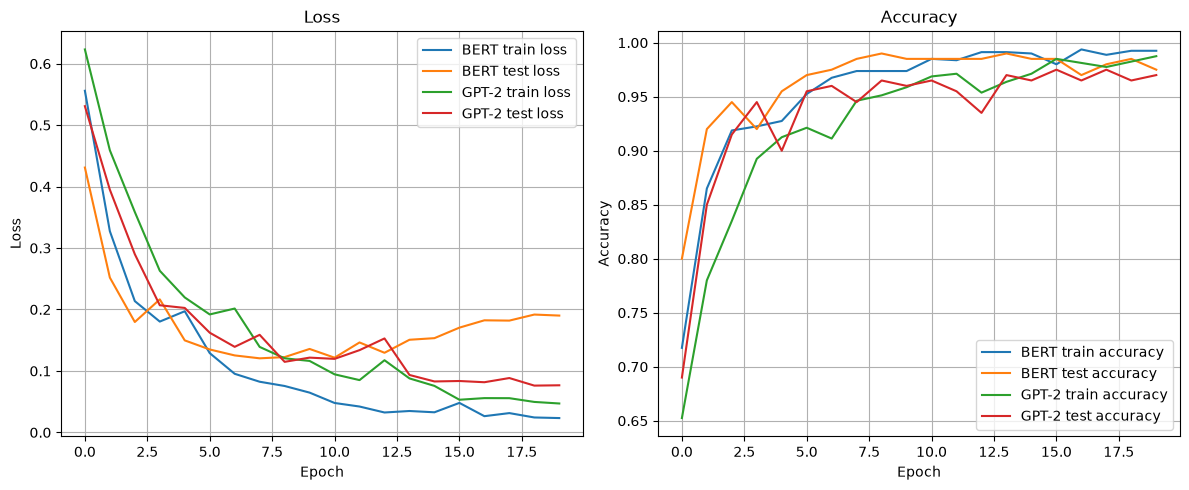

In [14]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_bert['train_loss'], label='BERT train loss')
plt.plot(history_bert['test_loss'], label='BERT test loss')
plt.plot(history_gpt2['train_loss'], label='GPT-2 train loss')
plt.plot(history_gpt2['test_loss'], label='GPT-2 test loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_bert['train_acc'], label='BERT train accuracy')
plt.plot(history_bert['test_acc'], label='BERT test accuracy')
plt.plot(history_gpt2['train_acc'], label='GPT-2 train accuracy')
plt.plot(history_gpt2['test_acc'], label='GPT-2 test accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## 10. Итоговые метрики

In [15]:
results = pd.DataFrame({
    'Model': ['BERT', 'GPT-2'],
    'Accuracy': [
        history_bert['test_acc'][-1],
        history_gpt2['test_acc'][-1]
    ],
    'F1-score': [
        history_bert['test_f1'][-1],
        history_gpt2['test_f1'][-1]
    ],
    'Final test loss': [
        history_bert['test_loss'][-1],
        history_gpt2['test_loss'][-1]
    ]
})

display(results)

,Model,Accuracy,F1-score,Final test loss
0,BERT,0.975,0.964539,0.190116
1,GPT-2,0.970,0.957143,0.076680


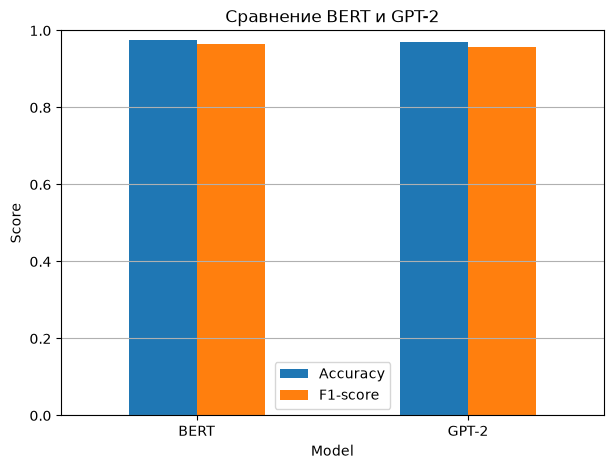

In [16]:
ax = results.set_index('Model')[['Accuracy', 'F1-score']].plot(
    kind='bar',
    figsize=(7, 5),
    ylim=(0, 1)
)
plt.title('Сравнение BERT и GPT-2')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

## 11. Вывод

In [17]:
best_model = results.sort_values('F1-score', ascending=False).iloc[0]

print(
    f"Лучший результат по F1-score показала модель {best_model['Model']}: "
    f"F1 = {best_model['F1-score']:.4f}, Accuracy = {best_model['Accuracy']:.4f}."
)

print(
    'Обе модели используют предобученные трансформерные эмбеддинги, поэтому даже '
    'простая полносвязная сеть поверх этих признаков способна хорошо отделять spam '
    'от ham. Для сравнения основным критерием выбран F1-score, так как классы '
    'несбалансированы и важно учитывать не только долю правильных ответов, но и '
    'качество определения spam-класса.'
)

Лучший результат по F1-score показала модель BERT: F1 = 0.9645, Accuracy = 0.9750.
Обе модели используют предобученные трансформерные эмбеддинги, поэтому даже простая полносвязная сеть поверх этих признаков способна хорошо отделять spam от ham. Для сравнения основным критерием выбран F1-score, так как классы несбалансированы и важно учитывать не только долю правильных ответов, но и качество определения spam-класса.


## Итоговый вывод

В работе использованы первые 1000 строк датасета email_text.csv. Тексты были очищены: приведены к нижнему регистру, раскрыты сокращения, удалены лишние пробелы, знаки пунктуации и стоп-слова, выполнена лемматизация.

Для получения эмбеддингов применялись две предобученные трансформерные модели: BERT (ert-base-uncased) и GPT-2 (gpt2). Поверх полученных векторов обучалась одинаковая простая нейронная сеть PyTorch для бинарной классификации spam/ham.

В текущем запуске получены результаты:

| Model | Accuracy | F1-score |
|---|---:|---:|
| BERT | 0.9750 | 0.9645 |
| GPT-2 | 0.9700 | 0.9571 |

Обе модели превысили требуемые пороги качества: для BERT требовались F1-score не ниже 0.85 и Accuracy не ниже 0.75, для GPT-2 — F1-score не ниже 0.84 и Accuracy не ниже 0.73. Лучший результат по F1-score показал BERT, но GPT-2 дал очень близкое качество. Это объяснимо: обе модели используют сильные предобученные языковые представления, а задача spam/ham хорошо решается уже простой полносвязной сетью поверх таких эмбеддингов.
